# =============================================================
# MODELO EM PRODUÇÃO — V4
# =============================================================
### Este é o modelo final seleccionado para o projecto.
### Melhorias face ao V3:
###   - Diff_Points substitui Diff_Ranking (correlação -0.97 entre si)
###   - Sample weights por tipo de competição (Mundial=10, Continental=3,
###   - Qualificação=2, Amigável=1)
### Métricas: Accuracy 60.7% (17/28) | Log-loss 0.885
### Simulador associado: 05b_simulator_frozen.ipynb
# =============================================================

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss
import joblib
import matplotlib.pyplot as plt

Treino V4: 17563 jogos
Tipo_Competicao
Qualificacao           12256
Torneio_Continental     4765
Mundial                  542
Name: count, dtype: int64

Teste: 28 jogos

Distribuição de pesos:
Tipo_Competicao
2     12256
3      4765
10      542
Name: count, dtype: int64

Baseline naive (sempre H): 0.536 (15/28)

Logistic Regression V4
  Accuracy:  0.607  (17/28 corretos)
  Log-loss:  0.922
              precision    recall  f1-score   support

           A       0.43      1.00      0.60         3
           D       0.00      0.00      0.00        10
           H       0.67      0.93      0.78        15

    accuracy                           0.61        28
   macro avg       0.37      0.64      0.46        28
weighted avg       0.40      0.61      0.48        28



C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


Random Forest V4
  Accuracy:  0.571  (16/28 corretos)
  Log-loss:  0.885
              precision    recall  f1-score   support

           A       0.50      1.00      0.67         3
           D       0.50      0.10      0.17        10
           H       0.60      0.80      0.69        15

    accuracy                           0.57        28
   macro avg       0.53      0.63      0.51        28
weighted avg       0.55      0.57      0.50        28


Ensemble V4
  Accuracy:  0.607  (17/28 corretos)
  Log-loss:  0.885
              precision    recall  f1-score   support

           A       0.43      1.00      0.60         3
           D       0.00      0.00      0.00        10
           H       0.67      0.93      0.78        15

    accuracy                           0.61        28
   macro avg       0.37      0.64      0.46        28
weighted avg       0.40      0.61      0.48        28


=== FEATURE IMPORTANCE V4 ===
                            feature  importance
                

C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hdlop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

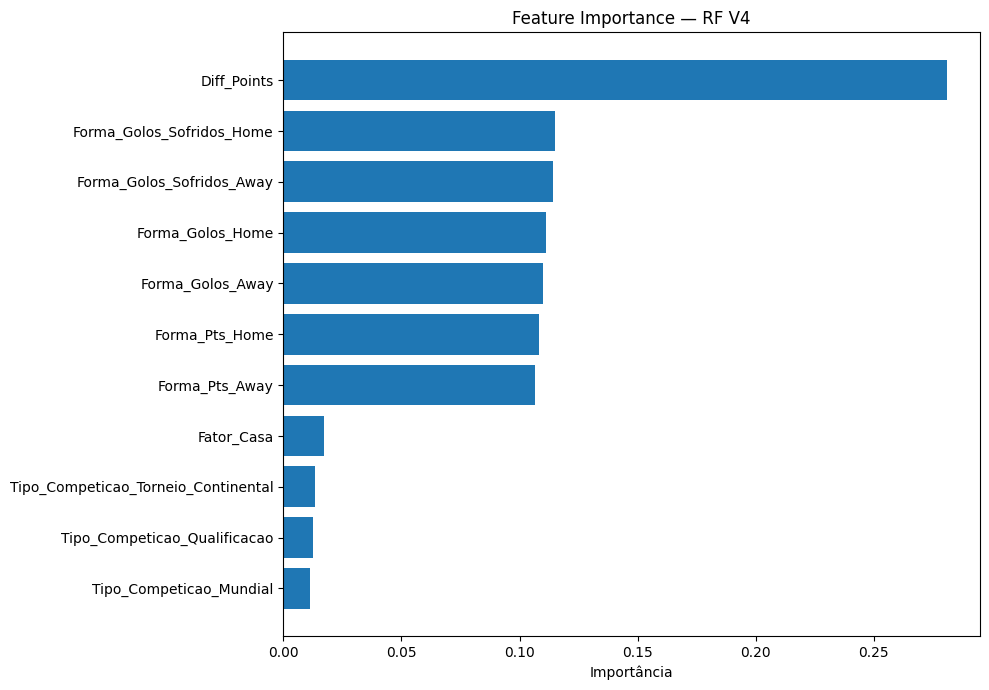


Modelos V4 guardados.


In [ ]:
# --- 1. Carregar dados ---
df_train_full = pd.read_csv("../data/df_train.csv")
df_full       = pd.read_csv("../data/df_full.csv")
df_train_full["date"] = pd.to_datetime(df_train_full["date"])
df_full["date"]       = pd.to_datetime(df_full["date"])

# --- 2. Dataset V4 ---
df_train = df_train_full[
    (df_train_full["Tipo_Competicao"] != "Amigavel") &
    (df_train_full["date"] >= "1990-01-01")
].copy()

print(f"Treino V4: {len(df_train)} jogos")
print(df_train["Tipo_Competicao"].value_counts())

# --- 3. Conjunto de teste ---
df_test = df_full[
    (df_full["tournament"] == "FIFA World Cup") &
    (df_full["date"] >= "2026-06-11") &
    (df_full["home_score"].notna())
].copy()
print(f"\nTeste: {len(df_test)} jogos")

# --- 4. Features e targets ---
FEATURES_NUM = [
    "Diff_Points",
    "Fator_Casa",
    "Forma_Golos_Home",
    "Forma_Pts_Home",
    "Forma_Golos_Sofridos_Home",
    "Forma_Golos_Away",
    "Forma_Pts_Away",
    "Forma_Golos_Sofridos_Away",
]
FEATURES_CAT = ["Tipo_Competicao"]
FEATURES     = FEATURES_NUM + FEATURES_CAT

# Cap a 5.0
GOLOS_CAP = 5.0
for col in ["Forma_Golos_Home", "Forma_Golos_Away",
            "Forma_Golos_Sofridos_Home", "Forma_Golos_Sofridos_Away"]:
    df_train[col] = df_train[col].clip(upper=GOLOS_CAP)
    df_test[col]  = df_test[col].clip(upper=GOLOS_CAP)

X_train    = df_train[FEATURES]
y_clf      = df_train["Resultado"]
y_reg_home = df_train["home_score"]
y_reg_away = df_train["away_score"]

X_test = df_test[FEATURES]
y_test = df_test.apply(
    lambda r: "H" if r["home_score"] > r["away_score"]
    else ("D" if r["home_score"] == r["away_score"] else "A"),
    axis=1
)

# --- 5. Sample weights por tipo de competição ---
WEIGHTS = {
    "Mundial":             10,
    "Torneio_Continental":  3,
    "Qualificacao":         2,
    "Amigavel":             1,
}
sample_weights = df_train["Tipo_Competicao"].map(WEIGHTS).values
print(f"\nDistribuição de pesos:")
print(df_train["Tipo_Competicao"].map(WEIGHTS).value_counts())

# --- 6. Preprocessador ---
preprocessor = ColumnTransformer(transformers=[
    ("ohe",    OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ("scaler", RobustScaler(),                         FEATURES_NUM),
])

# --- 7. Modelos de Classificação ---
clf_lr = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
clf_rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

clf_lr.fit(X_train, y_clf, clf__sample_weight=sample_weights)
clf_rf.fit(X_train, y_clf, clf__sample_weight=sample_weights)

# --- 8. Ensemble V4 ---
class EnsembleClassifier:
    def __init__(self, clf_predict, clf_proba):
        self.clf_predict = clf_predict
        self.clf_proba   = clf_proba
        self.classes_    = clf_proba.classes_

    def predict(self, X):
        return self.clf_predict.predict(X)

    def predict_proba(self, X):
        return self.clf_proba.predict_proba(X)

ensemble = EnsembleClassifier(clf_lr, clf_rf)

# --- 9. Avaliação ---
baseline_acc = accuracy_score(y_test, ["H"] * len(y_test))
print(f"\nBaseline naive (sempre H): {baseline_acc:.3f} ({int(baseline_acc*len(y_test))}/{len(y_test)})")

for name, model in [("Logistic Regression V4", clf_lr),
                    ("Random Forest V4", clf_rf),
                    ("Ensemble V4", ensemble)]:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc     = accuracy_score(y_test, y_pred)
    ll      = log_loss(y_test, y_proba, labels=model.classes_)
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"  Accuracy:  {acc:.3f}  ({int(acc*len(y_test))}/{len(y_test)} corretos)")
    print(f"  Log-loss:  {ll:.3f}")
    print(classification_report(y_test, y_pred, target_names=["A","D","H"]))

# --- 10. Feature Importance RF V4 ---
ohe_features = list(
    clf_rf.named_steps["pre"]
    .named_transformers_["ohe"]
    .get_feature_names_out(["Tipo_Competicao"])
)
all_features = ohe_features + FEATURES_NUM
importances  = clf_rf.named_steps["clf"].feature_importances_

df_imp = pd.DataFrame({
    "feature":    all_features,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n=== FEATURE IMPORTANCE V4 ===")
print(df_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1])
ax.set_title("Feature Importance — RF V4")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

# --- 11. Modelos de Regressão ---
reg_home = Pipeline([("pre", preprocessor), ("reg", PoissonRegressor(max_iter=1000))])
reg_away = Pipeline([("pre", preprocessor), ("reg", PoissonRegressor(max_iter=1000))])
reg_home.fit(X_train, y_reg_home, reg__sample_weight=sample_weights)
reg_away.fit(X_train, y_reg_away, reg__sample_weight=sample_weights)

# --- 12. Guardar modelos V4 ---
joblib.dump(clf_lr,   "../models/model_v4_clf_lr.pkl")
joblib.dump(clf_rf,   "../models/model_v4_clf_rf.pkl")
joblib.dump(reg_home, "../models/model_v4_reg_home.pkl")
joblib.dump(reg_away, "../models/model_v4_reg_away.pkl")
print("\nModelos V4 guardados.")

Accuracy manteve-se (17/28) mas log-loss subiu ligeiramente de 0.856 → 0.885. O V3 continua a ser ligeiramente melhor em log-loss.

O sample_weight não melhorou as métricas — e há uma razão clara: os 542 jogos do Mundial no treino já estão a ter efeito via Diff_Points (que é uma feature muito mais forte). O peso adicional não acrescenta sinal novo.

Diff_Points domina com 28.1% — superior ao Diff_Ranking que tinha 27.2% no V3

Distribuição das restantes features ainda mais equilibrada (~11% cada)

Tipo_Competicao_Mundial subiu de 0.4% para 1.1% — o sample_weight teve algum efeito aqui

O V3 Ensemble continua a ser o melhor modelo em log-loss (0.856). O V4 não regrediu mas também não melhorou. O Diff_Points é uma feature superior ao Diff_Ranking — essa decisão foi correcta. O sample_weight não trouxe ganho mensurável.
